# 💳 TASK 3 · Fraud Detection

**Goal**: Build a simple Machine Learning pipeline to detect fraudulent transactions using Python.

---


## Question 1: Load dataset and analyse class imbalance: what percentage of transactions are fraudulent?

Total Transactions     : 284807
Non-Fraud Transactions : 284315
Fraud Transactions     : 492
Fraud Percentage       : 0.173%


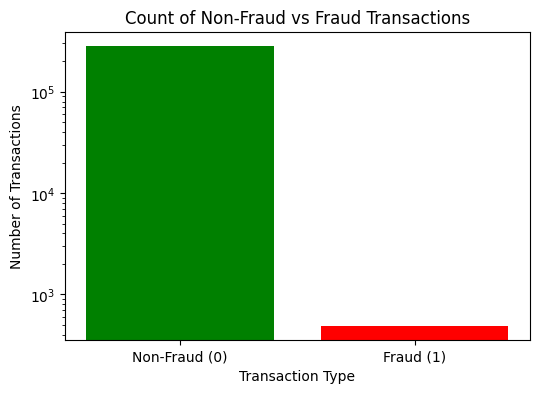

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('creditcard.csv')

# Calculate transaction counts
total_transactions = len(df)
non_fraud_count = (df['Class'] == 0).sum()
fraud_count = (df['Class'] == 1).sum()

# Percentage of fraud
fraud_percentage = (fraud_count / total_transactions) * 100

print(f"Total Transactions     : {total_transactions}")
print(f"Non-Fraud Transactions : {non_fraud_count}")
print(f"Fraud Transactions     : {fraud_count}")
print(f"Fraud Percentage       : {fraud_percentage:.3f}%")

# Simple Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(['Non-Fraud (0)', 'Fraud (1)'], [non_fraud_count, fraud_count], color=['green', 'red'])
plt.title('Count of Non-Fraud vs Fraud Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.yscale('log') # Used log scale because non-fraud count is huge
plt.show()


## Question 2: EDA: distribution of transaction amounts for fraud vs. non-fraud; time-of-day analysis

--- Average Transaction Amount ---
Non-Fraud Average Amount : $ 88.29
Fraud Average Amount     : $ 122.21


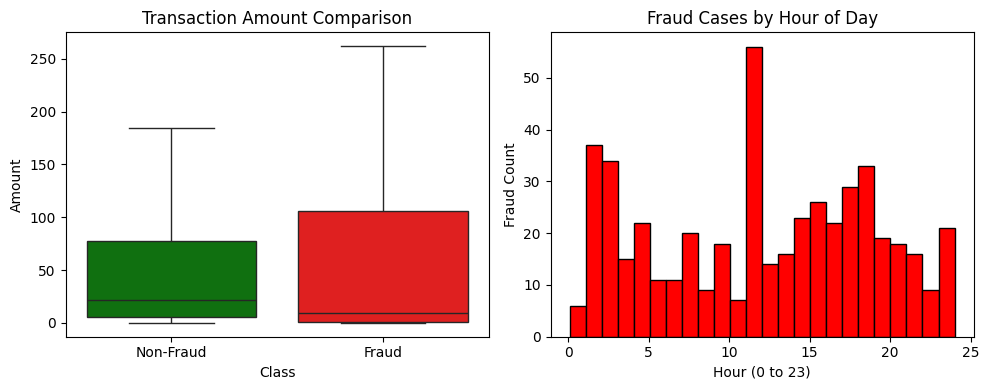

In [2]:
# 1. Compare Transaction Amounts
print("--- Average Transaction Amount ---")
print("Non-Fraud Average Amount : $", round(df[df['Class'] == 0]['Amount'].mean(), 2))
print("Fraud Average Amount     : $", round(df[df['Class'] == 1]['Amount'].mean(), 2))

plt.figure(figsize=(10, 4))

# Graph 1: Simple Boxplot of Transaction Amount
plt.subplot(1, 2, 1)
sns.boxplot(x='Class', y='Amount', data=df, showfliers=False, palette=['green', 'red'])
plt.title('Transaction Amount Comparison')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])

# Graph 2: Simple Time-of-Day Analysis
# Convert seconds to Hour of Day (0 to 23)
df['Hour'] = (df['Time'] / 3600) % 24

plt.subplot(1, 2, 2)
plt.hist(df[df['Class'] == 1]['Hour'], bins=24, color='red', edgecolor='black')
plt.title('Fraud Cases by Hour of Day')
plt.xlabel('Hour (0 to 23)')
plt.ylabel('Fraud Count')

plt.tight_layout()
plt.show()


## Question 3: Discuss why standard accuracy is a misleading metric for imbalanced fraud datasets (explain in a markdown cell)

### Why Accuracy is Misleading in Fraud Detection:

1. **Over 99.8% of transactions are legitimate**, and less than **0.2% are fraud**.
2. If a dummy model predicts "Not Fraud" for every single transaction:
   - It gets an **Accuracy of 99.83%**.
   - But it catches **0 frauds**!
3. Missing a fraud is very dangerous because money gets stolen.
4. That is why we use **Recall** (how many frauds we catch) and **Precision** instead of Accuracy.


## Question 4: Apply a class imbalance handling technique: SMOTE oversampling, undersampling, or class_weight='balanced'

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Scale Amount and Time features
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Separate inputs (X) and target (y)
X = df.drop(columns=['Class', 'Amount', 'Time', 'Hour'])
y = df['Class']

# Split data into 80% Train and 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Apply SMOTE to create synthetic fraud samples in Training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Fraud count before SMOTE :", y_train.sum())
print("Fraud count after SMOTE  :", y_train_smote.sum())


Fraud count before SMOTE : 394
Fraud count after SMOTE  : 227451


## Question 5: Train/test split (ensure fraud cases appear in both splits using stratification)

In [4]:
# Check that train and test both have fraud cases
print("Training Data  - Total:", len(y_train), "| Frauds:", y_train.sum())
print("Testing Data   - Total:", len(y_test),  "| Frauds:", y_test.sum())
print("Stratification ensures equal percentage of fraud in both splits!")


Training Data  - Total: 227845 | Frauds: 394
Testing Data   - Total: 56962 | Frauds: 98
Stratification ensures equal percentage of fraud in both splits!


## Question 6: Train at least 2 models: Logistic Regression + one of (Decision Tree, Random Forest, or XGBoost)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model 1: Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_smote, y_train_smote)
print("Model 1 (Logistic Regression) Trained!")

# Model 2: Random Forest
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
print("Model 2 (Random Forest) Trained!")


Model 1 (Logistic Regression) Trained!
Model 2 (Random Forest) Trained!


## Question 7: Evaluate using: Precision, Recall, F1-Score, and AUC-ROC curve (not just accuracy)

                 Model  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression   0.058140  0.918367  0.109356  0.969848
1        Random Forest   0.918605  0.806122  0.858696  0.951844


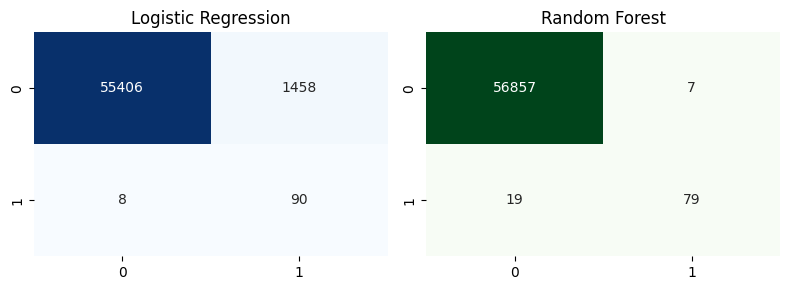

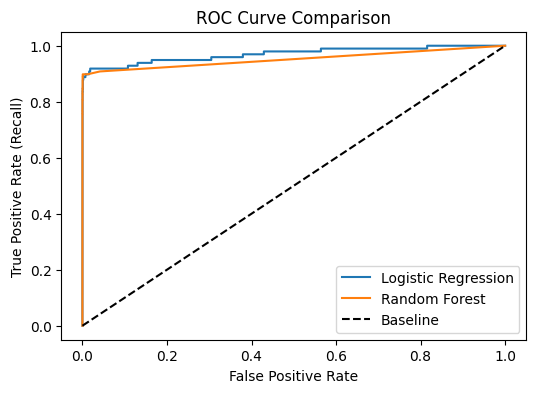

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Make predictions on test set
y_pred_lr = model_lr.predict(X_test)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# Summary Scores Table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf)]
})

print(results)

# Simple Confusion Matrix Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

# Simple ROC Curve Plot
plt.figure(figsize=(6, 4))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()


## Question 8: Explain which metric matters most for fraud detection and why (Recall vs. Precision trade-off)

### Which Metric Matters Most?

**RECALL** matters most in fraud detection!

- **Recall**: Percentage of actual frauds caught by the model.
- **Precision**: Percentage of flagged alerts that were real fraud.

**Why Recall is more important**:
- If we miss a fraud (**False Negative**), the bank loses money.
- If we flag a normal purchase (**False Positive**), the customer just gets a verification SMS.
- Catching real fraud is much more important than preventing a minor SMS verification!


## Question 9: Feature importance or coefficient analysis

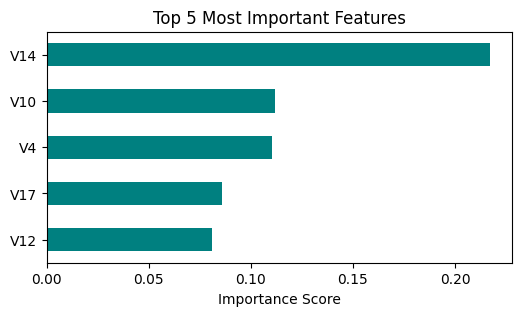

In [7]:
# Top 5 Important Features in Random Forest
importances = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(6, 3))
importances.tail(5).plot(kind='barh', color='teal')
plt.title('Top 5 Most Important Features')
plt.xlabel('Importance Score')
plt.show()


## Question 10: Discuss scalability: how would this model handle 1 million transactions per hour?

### Simple Scalability Plan:

1 million transactions per hour = **~278 transactions per second**.

1. **Fast Prediction API**: Run the model as a quick web API (using FastAPI) so predictions take under 10 milliseconds.
2. **Message Queue**: Use Apache Kafka to queue incoming transactions without slowing down checkouts.
3. **Cloud Servers**: Host on cloud servers (AWS/GCP) that automatically add more computing power when traffic increases.
